# COMP-3800 Project #1 – Final Draft

## Student Performance in Exams

**Name:** Jesse Blissett
**Date:** September 20, 2026  
**GitHub Repository:** ADD GITHUB LINK HERE

In [47]:
# Import the libraries used throughout the project.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display plots inside the Jupyter Notebook.
%matplotlib inline

In [48]:
# Set the same color for each subject in all of the bar charts.
subject_colors = {
    "math score": "tab:blue",
    "reading score": "tab:orange",
    "writing score": "tab:green"
}

In [49]:
# Load the Kaggle dataset.
students = pd.read_csv("StudentsPerformance.csv")

students.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


# 1. Problem Statements

## Data Source

I used the **Student Performance in Exams** dataset from Kaggle.

Dataset link:  
https://www.kaggle.com/spscientist/student-performance-in-exams/data

The dataset has 1,000 student records and 8 columns. It includes gender, race/ethnicity, parental level of education, lunch, test preparation course, and math, reading, and writing scores.

## Main Question

**How are different student characteristics and educational factors related to student exam performance?**

## Question A

**Do students who completed the test preparation course have different average exam scores than students who did not complete the course?**

## Question B

**How do average math, reading, and writing scores differ between male and female students?**

## Question C

**How do average exam scores differ based on students' parental level of education?**


In [50]:
# Check the number of rows and columns.
students.shape

(1000, 8)

In [51]:
# Check the column names and data types.
students.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


In [52]:
# Display descriptive statistics for numerical variables.
students.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


# 2. Data Cleaning

I checked the dataset before doing the main questions. The checks below cover unwanted columns, missing values, duplicate rows, data types, categorical values, and possible numeric outliers.


## 2.1 Unwanted Features


In [53]:
# Display all columns.
students.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='str')

All eight columns are useful for this project, so I did not remove any columns.


## 2.2 Missing Values


In [54]:
# Check for missing values in every column.
students.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

There are no missing values in the dataset, so I did not have to remove or replace any values for this step.


## 2.3 Duplicate Rows


In [55]:
# Check for duplicate rows.
students.duplicated().sum()

np.int64(0)

There are no duplicate rows, so no rows needed to be removed.


## 2.4 Data Types


In [56]:
# Check the data type of each column.
students.dtypes

gender                           str
race/ethnicity                   str
parental level of education      str
lunch                            str
test preparation course          str
math score                     int64
reading score                  int64
writing score                  int64
dtype: object

The five category columns are stored as object values, and the three exam scores are stored as integers. These data types work for the analysis, so I did not change them.


## 2.5 Categorical Variables


In [57]:
# Check the values in the categorical columns.
categorical_columns = [
    "gender",
    "race/ethnicity",
    "parental level of education",
    "lunch",
    "test preparation course"
]

for column in categorical_columns:
    print("\n" + column)
    print(students[column].value_counts())


gender
gender
female    518
male      482
Name: count, dtype: int64

race/ethnicity
race/ethnicity
group C    319
group D    262
group B    190
group E    140
group A     89
Name: count, dtype: int64

parental level of education
parental level of education
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: count, dtype: int64

lunch
lunch
standard        645
free/reduced    355
Name: count, dtype: int64

test preparation course
test preparation course
none         642
completed    358
Name: count, dtype: int64


The category names are consistent in the dataset. I did not find spelling or capitalization differences that needed to be corrected.


## 2.6 Numeric Outliers


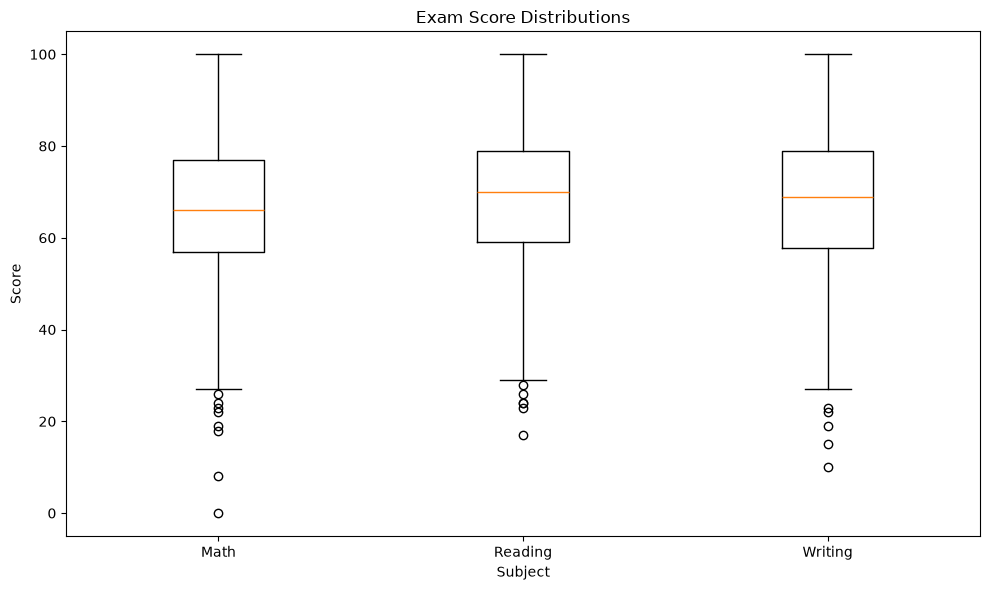

In [58]:
# Create boxplots for the three exam scores.
plt.figure(figsize=(10, 6))

plt.boxplot(
    [
        students["math score"],
        students["reading score"],
        students["writing score"]
    ],
    tick_labels=["Math", "Reading", "Writing"]
)

plt.title("Exam Score Distributions")
plt.xlabel("Subject")
plt.ylabel("Score")
plt.tight_layout()
plt.show()

In [59]:
# Check the IQR outlier limits for each exam score.
for column in ["math score", "reading score", "writing score"]:
    q1 = students[column].quantile(0.25)
    q3 = students[column].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = students[(students[column] < lower) | (students[column] > upper)]

    print(column)
    print("Lower limit:", lower)
    print("Upper limit:", upper)
    print("Number of IQR outliers:", len(outliers))
    print()

math score
Lower limit: 27.0
Upper limit: 107.0
Number of IQR outliers: 8

reading score
Lower limit: 29.0
Upper limit: 109.0
Number of IQR outliers: 6

writing score
Lower limit: 25.875
Upper limit: 110.875
Number of IQR outliers: 5



The boxplots show some lower scores that can look unusual, especially for math. However, exam scores have a real possible range from 0 to 100, so I did not automatically delete those observations just because they fall outside the IQR rule. There is no evidence in this dataset that those scores are data-entry mistakes.


# 3. Exploratory Data Analysis

## Question A

### Do students who completed the test preparation course have different average exam scores than students who did not complete the course?


In [60]:
# Calculate average math, reading, and writing scores
# by test preparation course status.

preparation_scores = students.groupby("test preparation course")[
    ["math score", "reading score", "writing score"]
].mean()

preparation_scores

,math score,reading score,writing score
test preparation course,,,
completed,69.695531,73.893855,74.418994
none,64.077882,66.534268,64.504673


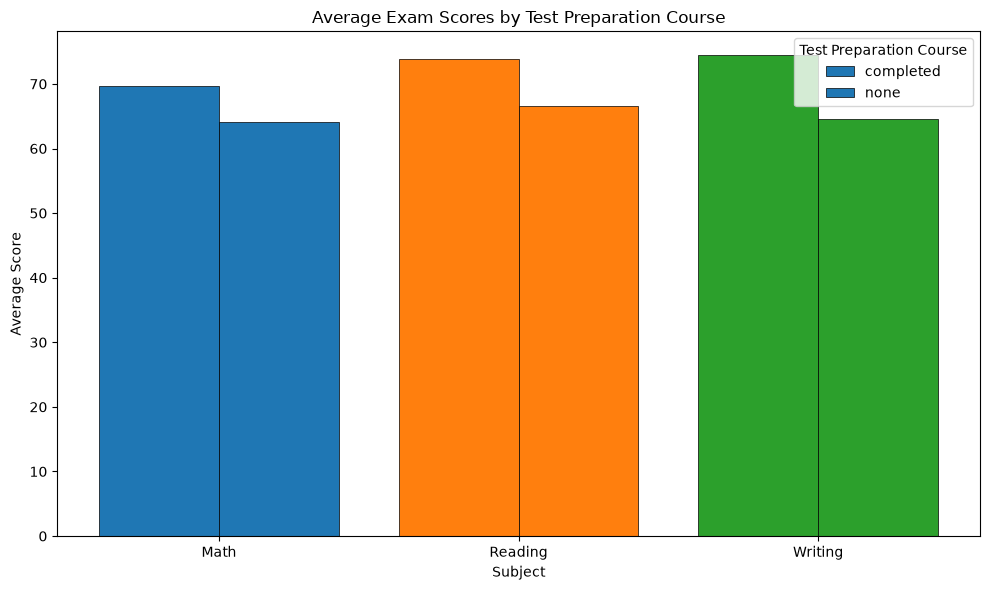

In [61]:
# Create a bar chart with subjects grouped together.
# Each subject keeps the same color across test-preparation groups.

subjects = preparation_scores.columns.tolist()
groups = preparation_scores.index.tolist()

fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(subjects))
width = 0.8 / len(groups)

for i, group in enumerate(groups):
    values = preparation_scores.loc[group, subjects]
    positions = x + (i - (len(groups) - 1) / 2) * width

    ax.bar(
        positions,
        values,
        width,
        color=[subject_colors[subject] for subject in subjects],
        edgecolor="black",
        linewidth=0.5,
        label=group
    )

ax.set_title("Average Exam Scores by Test Preparation Course")
ax.set_xlabel("Subject")
ax.set_ylabel("Average Score")
ax.set_xticks(x)
ax.set_xticklabels(["Math", "Reading", "Writing"])
ax.legend(title="Test Preparation Course")

plt.tight_layout()
plt.show()

In [62]:
# Calculate the difference between the completed and none groups.
preparation_difference = (
    preparation_scores.loc["completed"]
    - preparation_scores.loc["none"]
)

preparation_difference

math score       5.617649
reading score    7.359587
writing score    9.914322
dtype: float64

### Question A – Interpretation

Students who completed the test preparation course had higher average scores in all three subjects than students who did not complete it.

The average score differences were about **5.62 points in math**, **7.36 points in reading**, and **9.91 points in writing**. The biggest difference was in **writing**.

This shows a difference between the two groups in this dataset. It does not by itself prove that the preparation course caused the higher scores.


## Question B

### How do average math, reading, and writing scores differ between male and female students?


In [63]:
# Calculate average exam scores by gender.

gender_scores = students.groupby("gender")[
    ["math score", "reading score", "writing score"]
].mean()

gender_scores

,math score,reading score,writing score
gender,,,
female,63.633205,72.608108,72.467181
male,68.728216,65.473029,63.311203


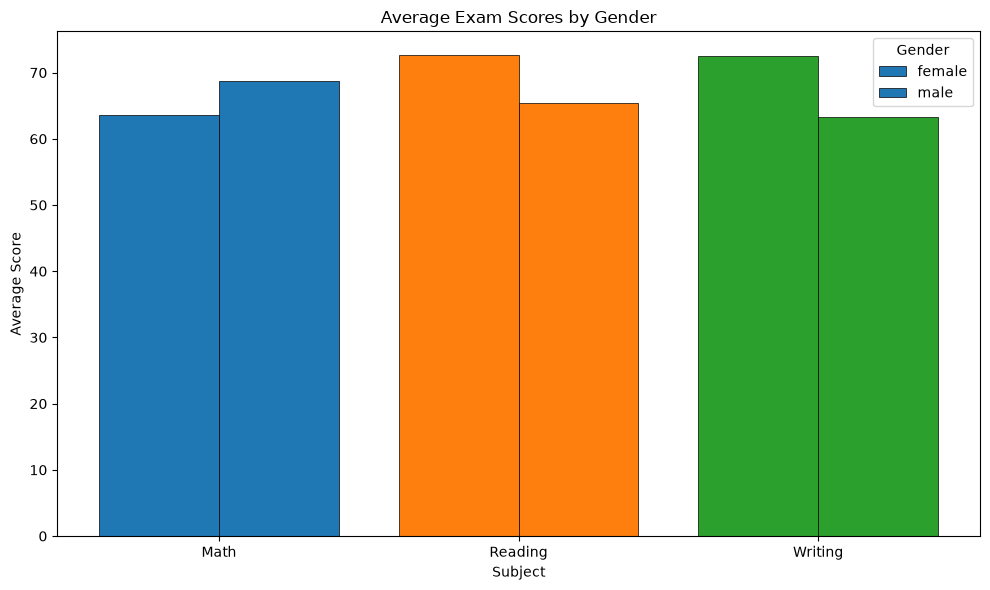

In [64]:
# Create a bar chart with subjects grouped together.
# Each subject keeps the same color across male and female groups.

subjects = gender_scores.columns.tolist()
groups = gender_scores.index.tolist()

fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(subjects))
width = 0.8 / len(groups)

for i, group in enumerate(groups):
    values = gender_scores.loc[group, subjects]
    positions = x + (i - (len(groups) - 1) / 2) * width

    ax.bar(
        positions,
        values,
        width,
        color=[subject_colors[subject] for subject in subjects],
        edgecolor="black",
        linewidth=0.5,
        label=group
    )

ax.set_title("Average Exam Scores by Gender")
ax.set_xlabel("Subject")
ax.set_ylabel("Average Score")
ax.set_xticks(x)
ax.set_xticklabels(["Math", "Reading", "Writing"])
ax.legend(title="Gender")

plt.tight_layout()
plt.show()

In [65]:
# Calculate the difference between female and male averages.
gender_difference = (
    gender_scores.loc["female"]
    - gender_scores.loc["male"]
)

gender_difference

math score      -5.095011
reading score    7.135079
writing score    9.155978
dtype: float64

### Question B – Interpretation

The average scores are different between male and female students, but the difference depends on the subject.

Female students had higher average **reading scores by 7.14 points** and higher average **writing scores by 9.16 points**. Male students had the higher average **math score by 5.10 points**.

The largest difference was in **writing**. These results describe the averages in this dataset and do not explain why the differences occur.


## Question C

### How do average exam scores differ based on students' parental level of education?


In [66]:
# Calculate average exam scores by parental level of education.

parental_scores = students.groupby(
    "parental level of education"
)[["math score", "reading score", "writing score"]].mean()

parental_scores

,math score,reading score,writing score
parental level of education,,,
associate's degree,67.882883,70.927928,69.896396
bachelor's degree,69.389831,73.000000,73.381356
high school,62.137755,64.704082,62.448980
master's degree,69.745763,75.372881,75.677966
some college,67.128319,69.460177,68.840708
some high school,63.497207,66.938547,64.888268


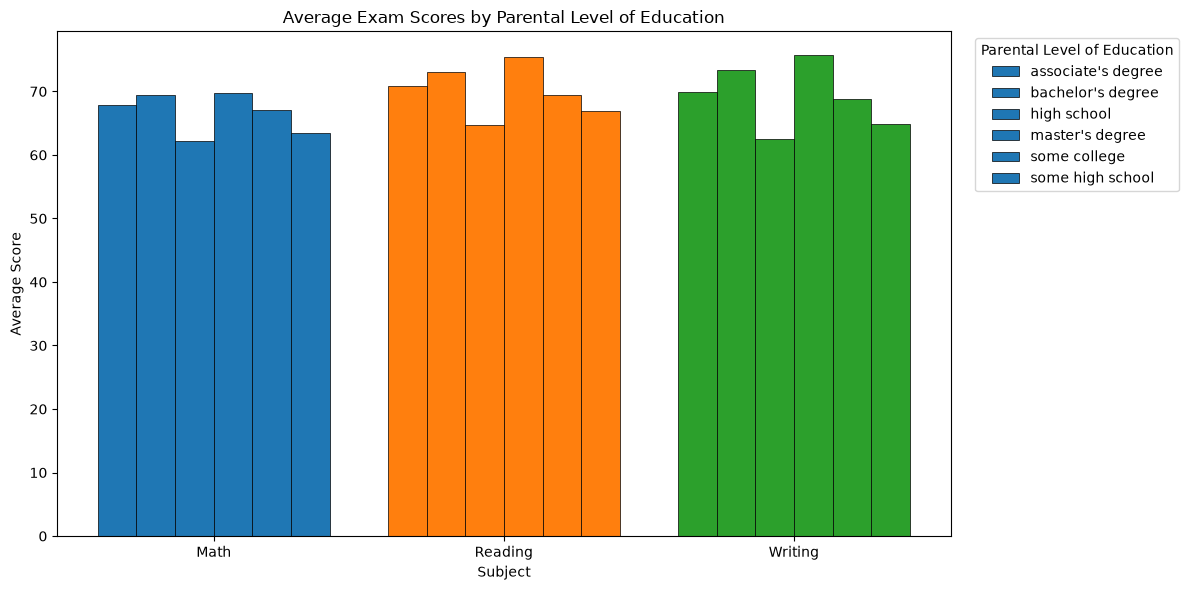

In [67]:
# Create a bar chart with subjects grouped together.
# Each subject keeps the same color across parental education groups.

subjects = parental_scores.columns.tolist()
groups = parental_scores.index.tolist()

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(subjects))
width = 0.8 / len(groups)

for i, group in enumerate(groups):
    values = parental_scores.loc[group, subjects]
    positions = x + (i - (len(groups) - 1) / 2) * width

    ax.bar(
        positions,
        values,
        width,
        color=[subject_colors[subject] for subject in subjects],
        edgecolor="black",
        linewidth=0.5,
        label=group
    )

ax.set_title("Average Exam Scores by Parental Level of Education")
ax.set_xlabel("Subject")
ax.set_ylabel("Average Score")
ax.set_xticks(x)
ax.set_xticklabels(["Math", "Reading", "Writing"])

ax.legend(
    title="Parental Level of Education",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

### Question C – Interpretation

The results show differences in average exam scores across the different parental education groups. The pattern can be compared across math, reading, and writing using the table and bar chart. The differences are not exactly the same for every subject or parental education group.

These results show an association between parental level of education and differences in average exam scores in this dataset. They do not by themselves show that parental education caused the differences.


# 4. Summary

This project looked at how different student characteristics and educational factors are related to exam performance using the Student Performance in Exams dataset. I checked the data first and found 1,000 rows, no missing values, no duplicate rows, and data types that were appropriate for the analysis.

For Question A, students who completed the test preparation course had higher average scores in math, reading, and writing than students who did not complete the course. The largest difference was in writing.

For Question B, the average scores were different by gender. Female students had higher average reading and writing scores, while male students had a higher average math score.

For Question C, the average exam scores differed across the different parental level of education groups. The size of the differences varied across math, reading, and writing.

Overall, the analysis shows differences in exam performance across several student characteristics and educational factors. These results describe patterns in this dataset, but they do not explain why the differences exist. Further analysis could look at race/ethnicity, lunch type, or combinations of several factors at the same time.


# 5. GitHub

After the notebook is finalized:

1. Create a GitHub repository for the project.
2. Upload this Jupyter Notebook.
3. Upload the `StudentsPerformance.csv` file if required for the repository.
4. Add the GitHub repository link at the top of this notebook.
5. Upload the completed `.ipynb` file to Moodle.
